## Machine Learning on Synthetic Data Adjustment

In [1]:
# DATA_PATH_URL = "../data/mixed/mixed_five_email_phishing_Phishing_and_Spam_Email_Campaigns_100+100.csv"
DATA_PATH_URL = "../data/mixed/mixed_five_email_phishing_Phishing_and_Spam_Email_Campaigns_500+500.csv"

🚀 Cybersecurity Synthetic Data Evaluation Framework
📊 Loading and exploring mixed dataset...
Dataset shape: (1000, 5)
Columns: ['body', 'label', 'source', 'subject', 'synthetic']

📈 Dataset Overview:
Total samples: 1000
Features: 4

🎯 Target Distribution (label):
label
1    625
0    375
Name: count, dtype: int64
Malicious ratio: 62.50%

🔬 Data Source Distribution:
Real samples: 500
Synthetic samples: 500
Synthetic ratio: 50.00%

📊 Synthetic vs Label Cross-tabulation:
label        0    1   All
synthetic                
0          243  257   500
1          132  368   500
All        375  625  1000

📝 Text Feature Analysis - subject:
Average length: 42.3 characters
Max length: 722.0
Min length: 2.0
Missing values: 2

📝 Text Feature Analysis - body:
Average length: 905.4 characters
Max length: 29831
Min length: 29
Missing values: 0

🔧 Preparing features and target...
Using text column: combined_text
Sample text: Monthly Sales Report Available for Review The monthly sales report for April 20

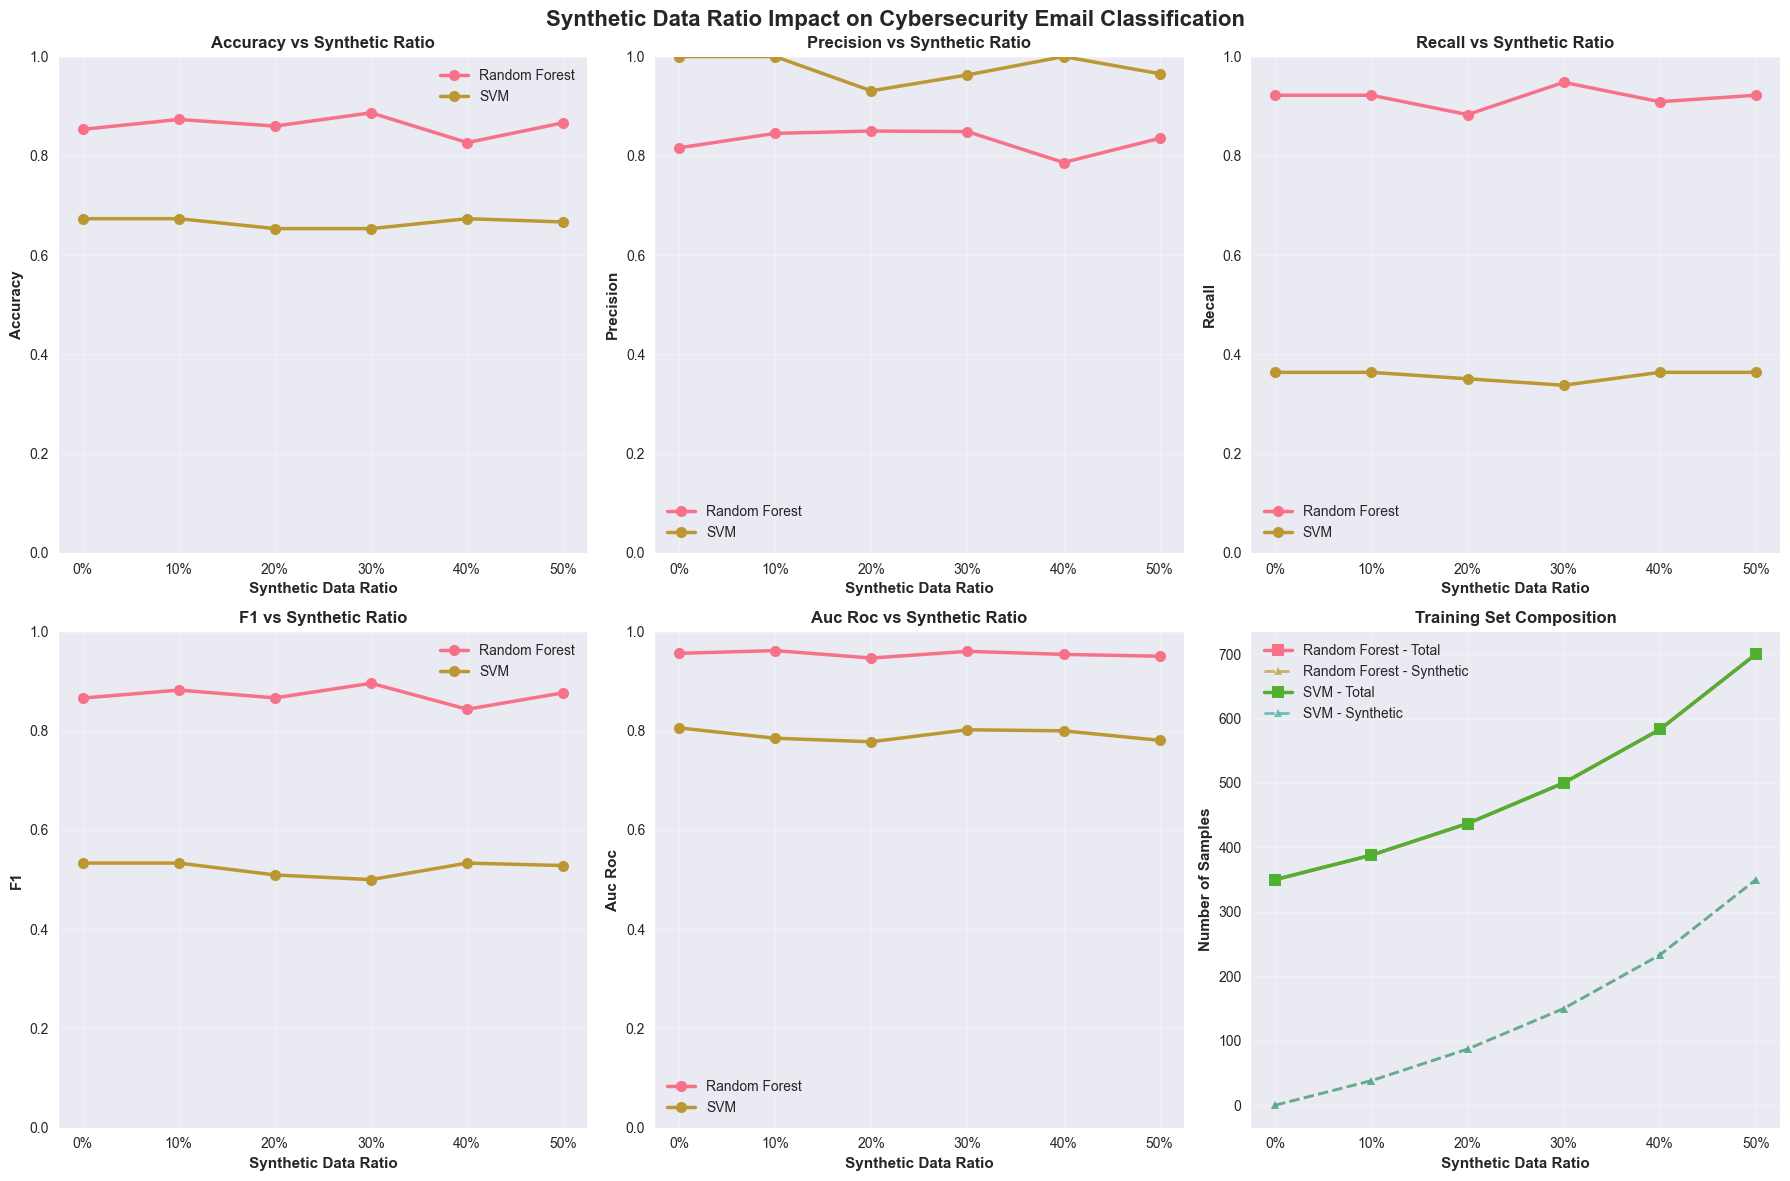


🔍 DETAILED ANALYSIS AND INSIGHTS

1️⃣ OPTIMAL SYNTHETIC RATIOS:

Random Forest:
  Best F1: 0.896 at 30% synthetic
  Best AUC: 0.962 at 10% synthetic

SVM:
  Best F1: 0.533 at 0% synthetic
  Best AUC: 0.806 at 0% synthetic

2️⃣ PERFORMANCE TRENDS:

Random Forest (baseline: F1=0.866, AUC=0.956):
  10%: F1 📈 +0.016, AUC 📈 +0.006
  20%: F1 📈 +0.000, AUC 📉 -0.010
  30%: F1 📈 +0.030, AUC 📈 +0.004
  40%: F1 📉 -0.022, AUC 📉 -0.002
  50%: F1 📈 +0.011, AUC 📉 -0.006

SVM (baseline: F1=0.533, AUC=0.806):
  10%: F1 ➡️ +0.000, AUC 📉 -0.021
  20%: F1 📉 -0.024, AUC 📉 -0.028
  30%: F1 📉 -0.033, AUC 📉 -0.004
  40%: F1 ➡️ +0.000, AUC 📉 -0.006
  50%: F1 📉 -0.005, AUC 📉 -0.025

3️⃣ MODEL COMPARISON:

Average Performance Across All Synthetic Ratios:
               accuracy  precision  recall     f1  auc_roc
model                                                     
Random Forest     0.861      0.830   0.918  0.872    0.955
SVM               0.666      0.977   0.357  0.523    0.792

4️⃣ KEY FINDINGS:
• Best

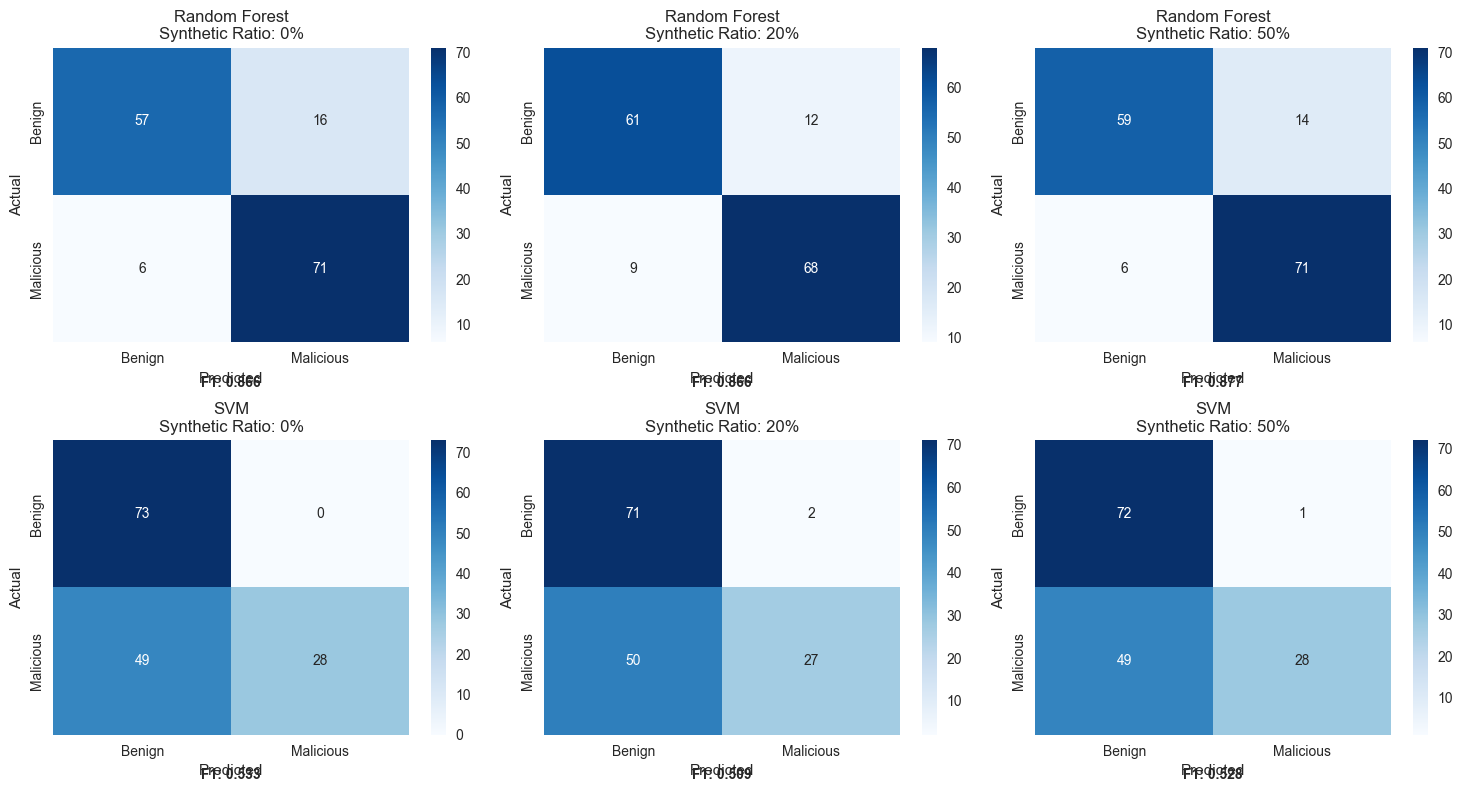

In [2]:
# Synthetic Data Ratio Evaluation for Cybersecurity Email Classification
# Research Question: How does synthetic data ratio (0%-50%) impact model performance on real-world threat detection?

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for professional plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("🚀 Cybersecurity Synthetic Data Evaluation Framework")
print("="*60)

# ================================================================================
# 1. DATA LOADING AND EXPLORATION
# ================================================================================

def load_and_explore_data(file_path):
    """Load mixed dataset and perform initial exploration."""
    print("📊 Loading and exploring mixed dataset...")
    
    # Load data
    df = pd.read_csv(file_path)
    
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print("\n" + "="*50)
    
    # Basic statistics
    print("📈 Dataset Overview:")
    print(f"Total samples: {len(df)}")
    print(f"Features: {len(df.columns) - 1}")  # Excluding target
    
    # Target distribution
    print(f"\n🎯 Target Distribution (label):")
    label_dist = df['label'].value_counts()
    print(label_dist)
    print(f"Malicious ratio: {label_dist.get(1, 0) / len(df):.2%}")
    
    # Synthetic vs Real distribution
    if 'synthetic' in df.columns:
        print(f"\n🔬 Data Source Distribution:")
        synthetic_dist = df['synthetic'].value_counts()
        print(f"Real samples: {synthetic_dist.get(0, 0)}")
        print(f"Synthetic samples: {synthetic_dist.get(1, 0)}")
        print(f"Synthetic ratio: {synthetic_dist.get(1, 0) / len(df):.2%}")
        
        # Cross-tabulation of synthetic and label
        print(f"\n📊 Synthetic vs Label Cross-tabulation:")
        crosstab = pd.crosstab(df['synthetic'], df['label'], margins=True)
        print(crosstab)
    
    # Text feature analysis
    text_columns = ['subject', 'body']
    for col in text_columns:
        if col in df.columns:
            print(f"\n📝 Text Feature Analysis - {col}:")
            print(f"Average length: {df[col].str.len().mean():.1f} characters")
            print(f"Max length: {df[col].str.len().max()}")
            print(f"Min length: {df[col].str.len().min()}")
            print(f"Missing values: {df[col].isnull().sum()}")
    
    return df

# Load data
data_path = DATA_PATH_URL
df = load_and_explore_data(data_path)

# ================================================================================
# 2. DATA PREPARATION AND PREPROCESSING
# ================================================================================

def prepare_features_and_target(df):
    """Prepare text features and target variable."""
    print("\n🔧 Preparing features and target...")
    
    # Combine text features
    text_features = []
    if 'subject' in df.columns:
        text_features.append('subject')
    if 'body' in df.columns:
        text_features.append('body')
    
    # Handle missing values
    for col in text_features:
        df[col] = df[col].fillna('')
    
    # Combine text columns
    if len(text_features) > 1:
        df['combined_text'] = df[text_features].apply(
            lambda x: ' '.join(x.astype(str)), axis=1
        )
        text_column = 'combined_text'
    else:
        text_column = text_features[0]
    
    print(f"Using text column: {text_column}")
    print(f"Sample text: {df[text_column].iloc[0][:100]}...")
    
    # Prepare features and target
    X = df[text_column]
    y = df['label']
    synthetic_flag = df.get('synthetic', pd.Series([0] * len(df)))  # Default to real if no synthetic column
    
    return X, y, synthetic_flag

X, y, synthetic_flag = prepare_features_and_target(df)

# ================================================================================
# 3. SYNTHETIC DATA RATIO EXPERIMENT FRAMEWORK
# ================================================================================

class SyntheticRatioExperiment:
    """Framework for evaluating different synthetic data ratios."""
    
    def __init__(self, X, y, synthetic_flag, test_size=0.3, random_state=42):
        self.X = X
        self.y = y
        self.synthetic_flag = synthetic_flag
        self.test_size = test_size
        self.random_state = random_state
        self.results = {}
        
        # Split into train and test (test set is always 100% real data)
        self._create_real_test_set()
        
    def _create_real_test_set(self):
        """Create a test set with only real data for realistic evaluation."""
        print("\n🎯 Creating real-world test set...")
        
        # Get indices of real data only
        real_indices = self.synthetic_flag[self.synthetic_flag == 0].index
        
        if len(real_indices) == 0:
            raise ValueError("No real data found! Cannot create realistic test set.")
        
        # Split real data into train and test
        real_X = self.X.loc[real_indices]
        real_y = self.y.loc[real_indices]
        
        self.X_real_train, self.X_test, self.y_real_train, self.y_test = train_test_split(
            real_X, real_y, 
            test_size=self.test_size, 
            random_state=self.random_state,
            stratify=real_y
        )
        
        # Get synthetic data (all synthetic data goes to training pool)
        synthetic_indices = self.synthetic_flag[self.synthetic_flag == 1].index
        self.X_synthetic = self.X.loc[synthetic_indices]
        self.y_synthetic = self.y.loc[synthetic_indices]
        
        print(f"Real training pool: {len(self.X_real_train)} samples")
        print(f"Synthetic training pool: {len(self.X_synthetic)} samples")
        print(f"Test set (100% real): {len(self.X_test)} samples")
        print(f"Test set class distribution: {self.y_test.value_counts().to_dict()}")
        
    def create_training_set(self, synthetic_ratio):
        """Create training set with specified synthetic ratio."""
        if synthetic_ratio == 0:
            # Pure real data
            return self.X_real_train, self.y_real_train
        
        # Calculate how many synthetic samples to add
        n_real = len(self.X_real_train)
        n_synthetic_needed = int((synthetic_ratio / (1 - synthetic_ratio)) * n_real)
        n_synthetic_available = len(self.X_synthetic)
        
        # Use available synthetic samples (with replacement if needed)
        if n_synthetic_needed <= n_synthetic_available:
            synthetic_sample = self.X_synthetic.sample(
                n=n_synthetic_needed, 
                random_state=self.random_state
            )
            synthetic_y_sample = self.y_synthetic.loc[synthetic_sample.index]
        else:
            # Use all synthetic data and sample with replacement
            print(f"⚠️  Warning: Need {n_synthetic_needed} synthetic samples but only {n_synthetic_available} available.")
            print(f"Using all available synthetic samples.")
            synthetic_sample = self.X_synthetic
            synthetic_y_sample = self.y_synthetic
            n_synthetic_needed = n_synthetic_available
        
        # Combine real and synthetic data
        X_train = pd.concat([self.X_real_train, synthetic_sample], ignore_index=True)
        y_train = pd.concat([self.y_real_train, synthetic_y_sample], ignore_index=True)
        
        # Shuffle the combined training set
        indices = np.random.RandomState(self.random_state).permutation(len(X_train))
        X_train = X_train.iloc[indices].reset_index(drop=True)
        y_train = y_train.iloc[indices].reset_index(drop=True)
        
        actual_ratio = n_synthetic_needed / len(X_train)
        print(f"Training set created: {len(X_train)} samples "
              f"({len(self.X_real_train)} real + {n_synthetic_needed} synthetic)")
        print(f"Actual synthetic ratio: {actual_ratio:.1%}")
        
        return X_train, y_train
    
    def evaluate_models(self, synthetic_ratios=[0, 0.1, 0.2, 0.3, 0.4, 0.5]):
        """Evaluate models across different synthetic ratios."""
        print(f"\n🧪 Starting evaluation across synthetic ratios: {synthetic_ratios}")
        
        # Define models
        models = {
            'Random Forest': Pipeline([
                ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
                ('classifier', RandomForestClassifier(n_estimators=100, random_state=self.random_state))
            ]),
            'SVM': Pipeline([
                ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
                ('scaler', StandardScaler(with_mean=False)),  # For sparse matrices
                ('classifier', SVC(random_state=self.random_state, probability=True))
            ])
        }
        
        results = {}
        
        for ratio in synthetic_ratios:
            print(f"\n📊 Evaluating synthetic ratio: {ratio:.0%}")
            results[ratio] = {}
            
            # Create training set with current ratio
            X_train, y_train = self.create_training_set(ratio)
            
            for model_name, model in models.items():
                print(f"  🔄 Training {model_name}...")
                
                # Train model
                model.fit(X_train, y_train)
                
                # Predict on test set (always real data)
                y_pred = model.predict(self.X_test)
                y_pred_proba = model.predict_proba(self.X_test)[:, 1]
                
                # Calculate metrics
                metrics = {
                    'accuracy': accuracy_score(self.y_test, y_pred),
                    'precision': precision_score(self.y_test, y_pred, zero_division=0),
                    'recall': recall_score(self.y_test, y_pred, zero_division=0),
                    'f1': f1_score(self.y_test, y_pred, zero_division=0),
                    'auc_roc': roc_auc_score(self.y_test, y_pred_proba),
                    'training_size': len(X_train),
                    'synthetic_samples': len(X_train) - len(self.X_real_train)
                }
                
                # Cross-validation on training set
                cv_scores = cross_val_score(
                    model, X_train, y_train, 
                    cv=3, scoring='f1', 
                    n_jobs=-1
                )
                metrics['cv_f1_mean'] = cv_scores.mean()
                metrics['cv_f1_std'] = cv_scores.std()
                
                results[ratio][model_name] = metrics
                
                print(f"    ✅ {model_name} - F1: {metrics['f1']:.3f}, "
                      f"AUC: {metrics['auc_roc']:.3f}, "
                      f"Precision: {metrics['precision']:.3f}, "
                      f"Recall: {metrics['recall']:.3f}")
        
        self.results = results
        return results

# ================================================================================
# 4. RUN EXPERIMENTS
# ================================================================================

# Initialize experiment
print("\n🚀 Initializing Synthetic Ratio Experiment...")
experiment = SyntheticRatioExperiment(X, y, synthetic_flag, test_size=0.3, random_state=42)

# Run evaluation across different synthetic ratios
synthetic_ratios = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
results = experiment.evaluate_models(synthetic_ratios)

# ================================================================================
# 5. RESULTS ANALYSIS AND VISUALIZATION
# ================================================================================

def analyze_and_visualize_results(results):
    """Analyze and visualize experimental results."""
    print("\n📊 Analyzing and visualizing results...")
    
    # Convert results to DataFrame for easier analysis
    rows = []
    for ratio, models in results.items():
        for model_name, metrics in models.items():
            row = {'synthetic_ratio': ratio, 'model': model_name}
            row.update(metrics)
            rows.append(row)
    
    results_df = pd.DataFrame(rows)
    
    # Summary statistics
    print("\n📈 Results Summary:")
    print(results_df.groupby(['model'])[['accuracy', 'precision', 'recall', 'f1', 'auc_roc']].agg(['mean', 'std']).round(3))
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Synthetic Data Ratio Impact on Cybersecurity Email Classification', fontsize=16, fontweight='bold')
    
    metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']
    
    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i//3, i%3]
        
        for model in results_df['model'].unique():
            model_data = results_df[results_df['model'] == model]
            ax.plot(model_data['synthetic_ratio'], model_data[metric], 
                   marker='o', linewidth=2.5, markersize=8, label=model)
        
        ax.set_xlabel('Synthetic Data Ratio', fontweight='bold')
        ax.set_ylabel(metric.replace('_', ' ').title(), fontweight='bold')
        ax.set_title(f'{metric.replace("_", " ").title()} vs Synthetic Ratio', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)
        
        # Format x-axis as percentages
        ax.set_xticks(synthetic_ratios)
        ax.set_xticklabels([f'{r:.0%}' for r in synthetic_ratios])
    
    # Training set size plot
    ax = axes[1, 2]
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        ax.plot(model_data['synthetic_ratio'], model_data['training_size'], 
               marker='s', linewidth=2.5, markersize=8, label=f'{model} - Total')
        ax.plot(model_data['synthetic_ratio'], model_data['synthetic_samples'], 
               marker='^', linewidth=2, markersize=6, linestyle='--', 
               label=f'{model} - Synthetic', alpha=0.7)
    
    ax.set_xlabel('Synthetic Data Ratio', fontweight='bold')
    ax.set_ylabel('Number of Samples', fontweight='bold')
    ax.set_title('Training Set Composition', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(synthetic_ratios)
    ax.set_xticklabels([f'{r:.0%}' for r in synthetic_ratios])
    
    plt.tight_layout()
    plt.show()
    
    return results_df

results_df = analyze_and_visualize_results(results)

# ================================================================================
# 6. DETAILED ANALYSIS AND INSIGHTS
# ================================================================================

def generate_insights(results_df):
    """Generate detailed insights from the experimental results."""
    print("\n🔍 DETAILED ANALYSIS AND INSIGHTS")
    print("="*60)
    
    # 1. Optimal synthetic ratios
    print("\n1️⃣ OPTIMAL SYNTHETIC RATIOS:")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        
        # Find best F1 score
        best_f1_idx = model_data['f1'].idxmax()
        best_f1_ratio = model_data.loc[best_f1_idx, 'synthetic_ratio']
        best_f1_score = model_data.loc[best_f1_idx, 'f1']
        
        # Find best AUC
        best_auc_idx = model_data['auc_roc'].idxmax()
        best_auc_ratio = model_data.loc[best_auc_idx, 'synthetic_ratio']
        best_auc_score = model_data.loc[best_auc_idx, 'auc_roc']
        
        print(f"\n{model}:")
        print(f"  Best F1: {best_f1_score:.3f} at {best_f1_ratio:.0%} synthetic")
        print(f"  Best AUC: {best_auc_score:.3f} at {best_auc_ratio:.0%} synthetic")
    
    # 2. Performance trends
    print("\n2️⃣ PERFORMANCE TRENDS:")
    baseline_performance = results_df[results_df['synthetic_ratio'] == 0][['model', 'f1', 'auc_roc']]
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        baseline_f1 = baseline_performance[baseline_performance['model'] == model]['f1'].iloc[0]
        baseline_auc = baseline_performance[baseline_performance['model'] == model]['auc_roc'].iloc[0]
        
        print(f"\n{model} (baseline: F1={baseline_f1:.3f}, AUC={baseline_auc:.3f}):")
        
        for ratio in [0.1, 0.2, 0.3, 0.4, 0.5]:
            row = model_data[model_data['synthetic_ratio'] == ratio]
            if not row.empty:
                f1_change = row['f1'].iloc[0] - baseline_f1
                auc_change = row['auc_roc'].iloc[0] - baseline_auc
                trend_f1 = "📈" if f1_change > 0 else "📉" if f1_change < 0 else "➡️"
                trend_auc = "📈" if auc_change > 0 else "📉" if auc_change < 0 else "➡️"
                
                print(f"  {ratio:.0%}: F1 {trend_f1} {f1_change:+.3f}, AUC {trend_auc} {auc_change:+.3f}")
    
    # 3. Model comparison
    print("\n3️⃣ MODEL COMPARISON:")
    avg_performance = results_df.groupby('model')[['accuracy', 'precision', 'recall', 'f1', 'auc_roc']].mean()
    print("\nAverage Performance Across All Synthetic Ratios:")
    print(avg_performance.round(3))
    
    # 4. Key findings
    print("\n4️⃣ KEY FINDINGS:")
    
    # Best overall model
    best_model = avg_performance['f1'].idxmax()
    best_f1 = avg_performance['f1'].max()
    print(f"• Best overall model: {best_model} (Avg F1: {best_f1:.3f})")
    
    # Synthetic data effectiveness
    improvement_count = 0
    total_comparisons = 0
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        baseline = model_data[model_data['synthetic_ratio'] == 0]['f1'].iloc[0]
        
        for ratio in [0.1, 0.2, 0.3, 0.4, 0.5]:
            synthetic_f1 = model_data[model_data['synthetic_ratio'] == ratio]['f1'].iloc[0]
            if synthetic_f1 > baseline:
                improvement_count += 1
            total_comparisons += 1
    
    improvement_rate = improvement_count / total_comparisons
    print(f"• Synthetic data improves performance in {improvement_rate:.1%} of cases")
    
    # Variance analysis
    print(f"\n• Performance stability:")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        f1_std = model_data['f1'].std()
        auc_std = model_data['auc_roc'].std()
        print(f"  {model}: F1 std={f1_std:.3f}, AUC std={auc_std:.3f}")

generate_insights(results_df)

# ================================================================================
# 7. CONFUSION MATRIX ANALYSIS
# ================================================================================

def analyze_confusion_matrices(experiment, synthetic_ratios=[0, 0.2, 0.5]):
    """Analyze confusion matrices for key synthetic ratios."""
    print(f"\n🎯 CONFUSION MATRIX ANALYSIS")
    print("="*60)
    
    models = {
        'Random Forest': Pipeline([
            ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
            ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
        ]),
        'SVM': Pipeline([
            ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
            ('scaler', StandardScaler(with_mean=False)),
            ('classifier', SVC(random_state=42, probability=True))
        ])
    }
    
    fig, axes = plt.subplots(len(models), len(synthetic_ratios), figsize=(15, 8))
    
    for i, (model_name, model) in enumerate(models.items()):
        for j, ratio in enumerate(synthetic_ratios):
            # Create training set and train model
            X_train, y_train = experiment.create_training_set(ratio)
            model.fit(X_train, y_train)
            
            # Predict and create confusion matrix
            y_pred = model.predict(experiment.X_test)
            cm = confusion_matrix(experiment.y_test, y_pred)
            
            # Plot confusion matrix
            ax = axes[i, j] if len(models) > 1 else axes[j]
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                       xticklabels=['Benign', 'Malicious'],
                       yticklabels=['Benign', 'Malicious'])
            ax.set_title(f'{model_name}\nSynthetic Ratio: {ratio:.0%}')
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Actual')
            
            # Calculate metrics for annotation
            tn, fp, fn, tp = cm.ravel()
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            
            # Add metrics as text
            ax.text(0.5, -0.15, f'F1: {f1:.3f}', transform=ax.transAxes, 
                   ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

analyze_confusion_matrices(experiment, [0, 0.2, 0.5])
